In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001
INPUT_SIZE = 28 * 28
HIDDEN_SIZE_1 = 256
HIDDEN_SIZE_2 = 128
NUM_CLASSES = 10

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [4]:
os.makedirs("saved_model", exist_ok=True)

In [5]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [7]:
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.41MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.7MB/s]


In [8]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
class ANNModel(nn.Module):
    def __init__(self):
        super(ANNModel, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(INPUT_SIZE, HIDDEN_SIZE_1),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(HIDDEN_SIZE_1, HIDDEN_SIZE_2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(HIDDEN_SIZE_2, NUM_CLASSES)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)


In [10]:
model = ANNModel().to(DEVICE)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [12]:
def train_model():
  train_losses = []
  train_accuracies = []

  for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

      images = images.to(DEVICE)
      labels = labels.to(DEVICE)

      outputs = model(images)
      loss = criterion(outputs, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      _, predicted = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

      epoch_loss = running_loss / len(train_loader)
      epoch_accuracy = 100 * correct / total

      train_losses.append(epoch_loss)
      train_accuracies.append(epoch_accuracy)

      print(
            f"Epoch [{epoch + 1}/{EPOCHS}], "
            f"Loss: {epoch_loss:.4f}, "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

  torch.save(model.state_dict(), "saved_model/ann_fashion_mnist_model.pth")
  print("Model saved successfully!")

  return train_losses, train_accuracies




In [13]:
def evaluate_model():
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

In [14]:
def plot_graph(losses, accuracies):
    plt.figure()
    plt.plot(losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.savefig("saved_model/fashion_loss_graph.png")
    plt.show()

    plt.figure()
    plt.plot(accuracies)
    plt.title("Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.savefig("saved_model/fashion_accuracy_graph.png")
    plt.show()

Streaming output truncated to the last 5000 lines.
Epoch [5/10], Loss: 0.2500, Accuracy: 86.58%
Epoch [5/10], Loss: 0.2504, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2508, Accuracy: 86.58%
Epoch [5/10], Loss: 0.2513, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2519, Accuracy: 86.56%
Epoch [5/10], Loss: 0.2522, Accuracy: 86.56%
Epoch [5/10], Loss: 0.2525, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2528, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2532, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2536, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2540, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2543, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2547, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2553, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2557, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2562, Accuracy: 86.56%
Epoch [5/10], Loss: 0.2566, Accuracy: 86.56%
Epoch [5/10], Loss: 0.2568, Accuracy: 86.57%
Epoch [5/10], Loss: 0.2571, Accuracy: 86.58%
Epoch [5/10], Loss: 0.2573, Accuracy: 86.58%
Epoch [5/10], Loss: 0.2577, Accuracy: 86.59%
Epoc

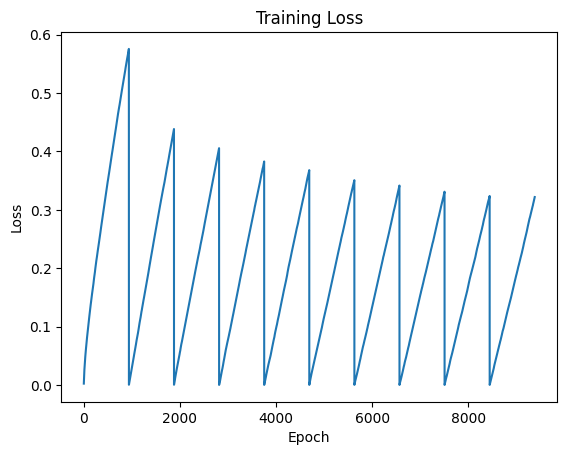

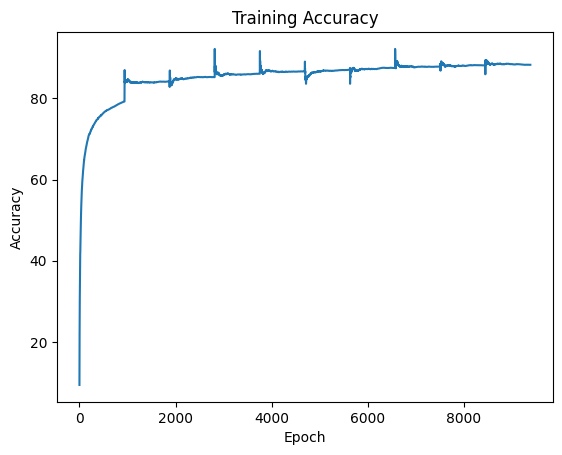

In [15]:
losses, accuracies = train_model()
evaluate_model()
plot_graph(losses, accuracies)

In [16]:
model.load_state_dict(
    torch.load(
        "saved_model/ann_fashion_mnist_model.pth",
        map_location=DEVICE
    )
)

model.eval()

ANNModel(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [17]:
# =========================
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [18]:
from PIL import Image

In [19]:
def predict_image(image_path):
    image = Image.open(image_path)
    image = transform(image)
    image = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)

    predicted_class = predicted.item()
    predicted_label = CLASS_NAMES[predicted_class]

    return predicted_class, predicted_label

In [22]:
image_path = "/content/images (1).jfif"

class_id, class_name = predict_image(image_path)

print(f"Predicted Class ID: {class_id}")
print(f"Predicted Label: {class_name}")

Predicted Class ID: 8
Predicted Label: Bag
